# PS03: Automated Financial Data Wrangling & Reporting Engine

## Step 1: Install and import Required Libraries

In [ ]:
!pip install openpyxl pyarrow

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Create Sample Branch Dataset

In [2]:
import pandas as pd
import random

# Bangalore Branch
bangalore = pd.DataFrame({
    'Transaction_ID': range(101, 201),
    'Date': pd.date_range(
        start='2025-01-01',
        periods=100
    ).strftime('%d-%m-%Y'),
    'Amount': [random.randint(3000, 15000) for _ in range(100)],
    'Branch': ['Bangalore'] * 100
})

bangalore.to_csv('Bangalore.csv', index=False)

# Mysore Branch
mysore = pd.DataFrame({
    'txn_id': range(201, 301),
    'transaction_date': pd.date_range(
        start='2025-01-01',
        periods=100
    ).strftime('%Y/%m/%d'),
    'revenue': [random.randint(4000, 18000) for _ in range(100)],
    'location': ['Mysore'] * 100
})

mysore.to_csv('Mysore.csv', index=False)

# Hubli Branch
hubli = pd.DataFrame({
    'ID': range(301, 401),
    'Date_of_Transaction': pd.date_range(
        start='2025-01-01',
        periods=100
    ).strftime('%d/%m/%Y'),
    'Amount_INR': [random.randint(3500, 17000) for _ in range(100)],
    'Branch_Name': ['Hubli'] * 100
})

hubli.to_excel('Hubli.xlsx', index=False)

print("records created for each branch")

records created for each branch


In [3]:
import os

print(os.listdir())

['.config', 'Bangalore.csv', 'Hubli.xlsx', 'Mysore.csv', 'sample_data']


In [4]:
bangalore_df = pd.read_csv("Bangalore.csv")
mysore_df = pd.read_csv("Mysore.csv")
hubli_df = pd.read_excel("Hubli.xlsx")

print("Bangalore Data")
print(bangalore_df)

print("\nMysore Data")
print(mysore_df)

print("\nHubli Data")
print(hubli_df)

Bangalore Data
    Transaction_ID        Date  Amount     Branch
0              101  01-01-2025   14942  Bangalore
1              102  02-01-2025    7104  Bangalore
2              103  03-01-2025    3189  Bangalore
3              104  04-01-2025    4077  Bangalore
4              105  05-01-2025    4757  Bangalore
..             ...         ...     ...        ...
95             196  06-04-2025   13158  Bangalore
96             197  07-04-2025   12914  Bangalore
97             198  08-04-2025   11230  Bangalore
98             199  09-04-2025    8171  Bangalore
99             200  10-04-2025    4074  Bangalore

[100 rows x 4 columns]

Mysore Data
    txn_id transaction_date  revenue location
0      201       2025/01/01    11128   Mysore
1      202       2025/01/02     6982   Mysore
2      203       2025/01/03    11197   Mysore
3      204       2025/01/04     6588   Mysore
4      205       2025/01/05     8686   Mysore
..     ...              ...      ...      ...
95     296       2025/04/0

## Step 3: Automated Data Ingestion


In [5]:
import os
import pandas as pd

dataframes = []

for file in os.listdir():

    if file.endswith(".csv"):
        print("Reading:", file)
        df = pd.read_csv(file)
        dataframes.append(df)

    elif file.endswith(".xlsx"):
        print("Reading:", file)
        df = pd.read_excel(file)
        dataframes.append(df)

print("\nTotal files loaded:", len(dataframes))

Reading: Bangalore.csv
Reading: Hubli.xlsx
Reading: Mysore.csv

Total files loaded: 3


## Step 4: Define Column Standardization Mapping

In [6]:
column_mapping = {

    # Transaction ID
    'Transaction_ID':'transaction_id',
    'txn_id':'transaction_id',
    'ID':'transaction_id',

    # Date
    'Date':'date',
    'transaction_date':'date',
    'Date_of_Transaction':'date',

    # Amount
    'Amount':'amount',
    'revenue':'amount',
    'Amount_INR':'amount',

    # Branch
    'Branch':'branch',
    'location':'branch',
    'Branch_Name':'branch'
}

print("Column mapping created")

Column mapping created


## Step 5: Apply Column Standardization


In [7]:
standardized_dfs = []

for df in dataframes:

    df = df.rename(columns=column_mapping)

    standardized_dfs.append(df)

print("Column names standardized")

for i, df in enumerate(standardized_dfs):

    print(f"\nDataFrame {i+1}")
    print(df.columns.tolist())

Column names standardized

DataFrame 1
['transaction_id', 'date', 'amount', 'branch']

DataFrame 2
['transaction_id', 'date', 'amount', 'branch']

DataFrame 3
['transaction_id', 'date', 'amount', 'branch']


In [8]:
standardized_dfs[0]


,transaction_id,date,amount,branch
0,101,01-01-2025,14942,Bangalore
1,102,02-01-2025,7104,Bangalore
2,103,03-01-2025,3189,Bangalore
3,104,04-01-2025,4077,Bangalore
4,105,05-01-2025,4757,Bangalore
...,...,...,...,...
95,196,06-04-2025,13158,Bangalore
96,197,07-04-2025,12914,Bangalore
97,198,08-04-2025,11230,Bangalore
98,199,09-04-2025,8171,Bangalore


In [9]:
standardized_dfs[1]


,transaction_id,date,amount,branch
0,301,01/01/2025,6059,Hubli
1,302,02/01/2025,5084,Hubli
2,303,03/01/2025,10337,Hubli
3,304,04/01/2025,16310,Hubli
4,305,05/01/2025,6449,Hubli
...,...,...,...,...
95,396,06/04/2025,4857,Hubli
96,397,07/04/2025,11082,Hubli
97,398,08/04/2025,15814,Hubli
98,399,09/04/2025,13622,Hubli


In [10]:
standardized_dfs[2]

,transaction_id,date,amount,branch
0,201,2025/01/01,11128,Mysore
1,202,2025/01/02,6982,Mysore
2,203,2025/01/03,11197,Mysore
3,204,2025/01/04,6588,Mysore
4,205,2025/01/05,8686,Mysore
...,...,...,...,...
95,296,2025/04/06,8675,Mysore
96,297,2025/04/07,17499,Mysore
97,298,2025/04/08,4276,Mysore
98,299,2025/04/09,15574,Mysore


## Step 6: Date Standardization

In [11]:
for df in standardized_dfs:

    df['date'] = pd.to_datetime(
        df['date'],
        format='mixed',
        dayfirst=True
    )

print("Date standardization completed")

Date standardization completed


## Step 7: Verify Standardized Datasets


In [12]:
for i, df in enumerate(standardized_dfs):

    print(f"\nBranch: {df['branch'].iloc[0]}")
    print(df.head())


Branch: Bangalore
   transaction_id       date  amount     branch
0             101 2025-01-01   14942  Bangalore
1             102 2025-01-02    7104  Bangalore
2             103 2025-01-03    3189  Bangalore
3             104 2025-01-04    4077  Bangalore
4             105 2025-01-05    4757  Bangalore

Branch: Hubli
   transaction_id       date  amount branch
0             301 2025-01-01    6059  Hubli
1             302 2025-01-02    5084  Hubli
2             303 2025-01-03   10337  Hubli
3             304 2025-01-04   16310  Hubli
4             305 2025-01-05    6449  Hubli

Branch: Mysore
   transaction_id       date  amount  branch
0             201 2025-01-01   11128  Mysore
1             202 2025-01-02    6982  Mysore
2             203 2025-01-03   11197  Mysore
3             204 2025-01-04    6588  Mysore
4             205 2025-01-05    8686  Mysore


## Step 8: Merge Standardized Datasets


In [13]:
master_df = pd.concat(
    standardized_dfs,
    ignore_index=True
)

print("All data merged successfully")

print("Total Records:", len(master_df))

master_df.head(10)

All data merged successfully
Total Records: 300


,transaction_id,date,amount,branch
0,101,2025-01-01,14942,Bangalore
1,102,2025-01-02,7104,Bangalore
2,103,2025-01-03,3189,Bangalore
3,104,2025-01-04,4077,Bangalore
4,105,2025-01-05,4757,Bangalore
5,106,2025-01-06,3651,Bangalore
6,107,2025-01-07,9740,Bangalore
7,108,2025-01-08,8250,Bangalore
8,109,2025-01-09,6336,Bangalore
9,110,2025-01-10,5814,Bangalore


## Step 9: Check for Missing Values

In [14]:
master_df.isnull().sum()

,0
transaction_id,0
date,0
amount,0
branch,0


## Step 10: Save Master Dataset as Parquet File

In [15]:
master_df.to_parquet(
    "financial_master.parquet",
    index=False
)

print("Parquet file saved successfully")

Parquet file saved successfully


In [16]:
import os

print(os.listdir())

['.config', 'Bangalore.csv', 'financial_master.parquet', 'Hubli.xlsx', 'Mysore.csv', 'sample_data']


## Step 11 : Verify Parquet File Creation

In [17]:
parquet_df = pd.read_parquet(
    "financial_master.parquet"
)

parquet_df.head(150)

,transaction_id,date,amount,branch
0,101,2025-01-01,14942,Bangalore
1,102,2025-01-02,7104,Bangalore
2,103,2025-01-03,3189,Bangalore
3,104,2025-01-04,4077,Bangalore
4,105,2025-01-05,4757,Bangalore
...,...,...,...,...
145,346,2025-02-15,7061,Hubli
146,347,2025-02-16,9132,Hubli
147,348,2025-02-17,10066,Hubli
148,349,2025-02-18,13508,Hubli


## Step 12: Chart 1- Revenue Trend Visualization

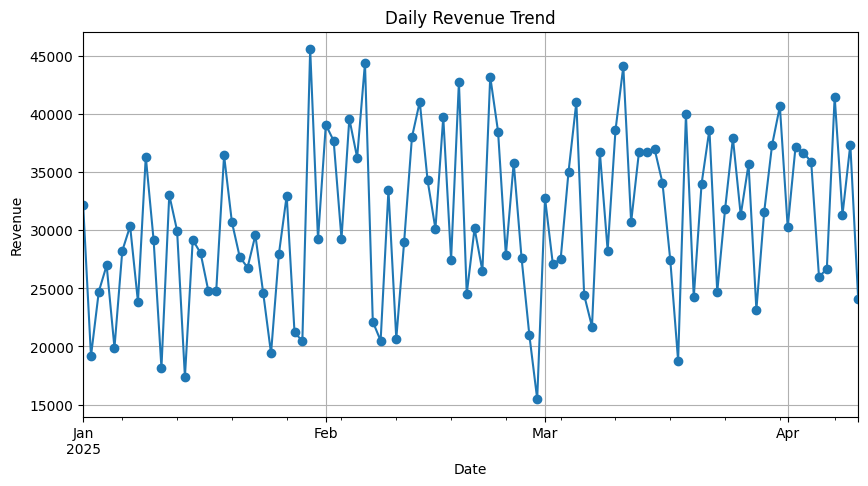

In [18]:
daily_revenue = master_df.groupby('date')['amount'].sum()

daily_revenue.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title('Daily Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.grid(True)

plt.savefig('chart1_revenue_trend.png')

plt.show()

## Step 13: Chart 2- Branch Revenue Comparison

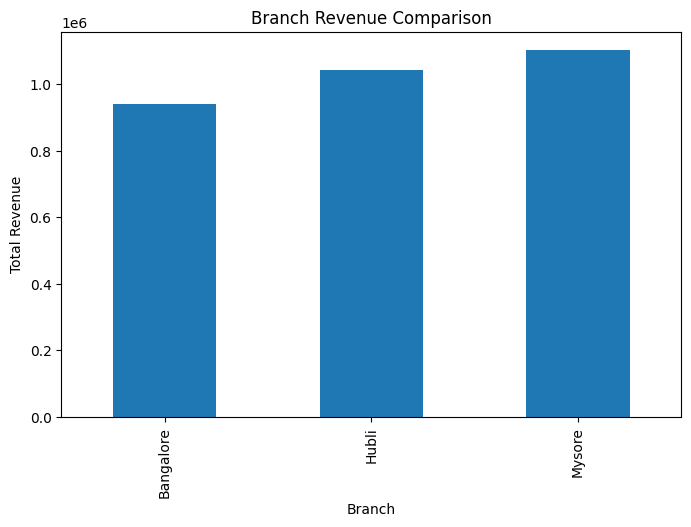

In [19]:
branch_revenue = master_df.groupby('branch')['amount'].sum()

branch_revenue.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Branch Revenue Comparison')
plt.xlabel('Branch')
plt.ylabel('Total Revenue')

plt.savefig('chart2_branch_comparison.png')

plt.show()

## Step 14: Chart 3- Transaction Amount Distribution

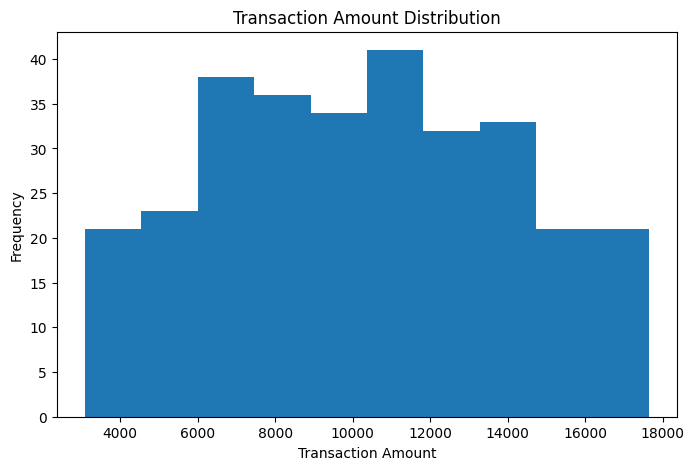

In [20]:
plt.figure(figsize=(8,5))

plt.hist(
    master_df['amount'],
    bins=10
)

plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

plt.savefig('chart3_amount_distribution.png')

plt.show()

## Step 15: Chart 4- Top 10 Highest Transactions

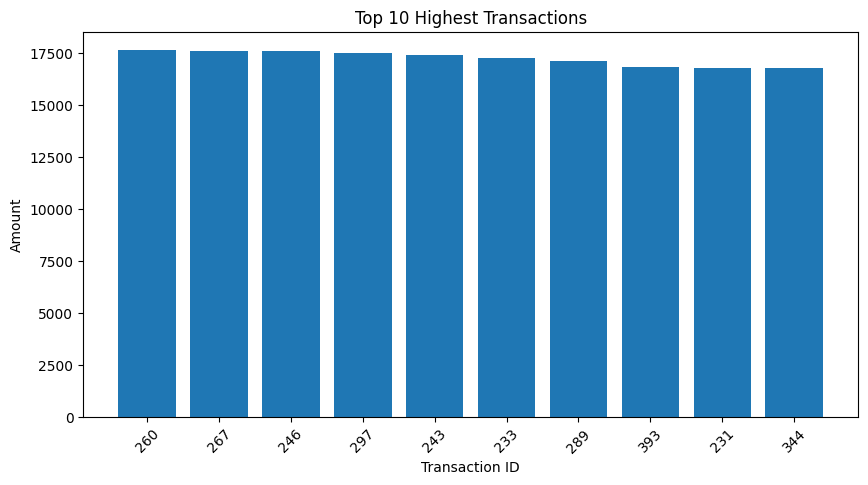

In [21]:
top_transactions = master_df.nlargest(10, 'amount')

plt.figure(figsize=(10,5))

plt.bar(
    top_transactions['transaction_id'].astype(str),
    top_transactions['amount']
)

plt.title('Top 10 Highest Transactions')
plt.xlabel('Transaction ID')
plt.ylabel('Amount')

plt.xticks(rotation=45)

plt.savefig('chart4_top_transactions.png')

plt.show()

## Step 16: Chart 5- Anomaly Detection Using Box Plot

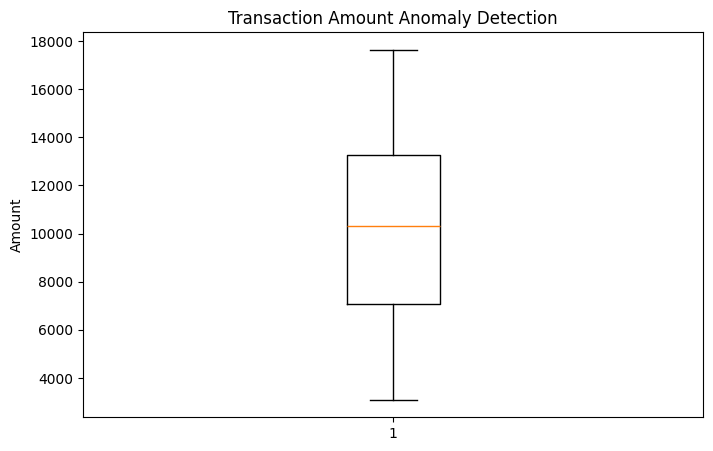

In [22]:
plt.figure(figsize=(8,5))

plt.boxplot(master_df['amount'])

plt.title('Transaction Amount Anomaly Detection')
plt.ylabel('Amount')

plt.savefig('chart5_anomaly_detection.png')

plt.show()

In [23]:
print(os.listdir())

['.config', 'Bangalore.csv', 'chart4_top_transactions.png', 'financial_master.parquet', 'chart3_amount_distribution.png', 'chart1_revenue_trend.png', 'Hubli.xlsx', 'Mysore.csv', 'chart5_anomaly_detection.png', 'chart2_branch_comparison.png', 'sample_data']
